In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import quantstream as qs
import os
import xarray as xr

import sys

import dotenv


dotenv.load_dotenv("../.env")

sys.path.append("../")

FMP_API_KEY = os.getenv("FMP_API_KEY")

In [81]:
# inspect ac
qs.__dict__

{'__name__': 'quantstream',
 '__doc__': 'QuantStream: A Python library for financial data analysis and portfolio management.',
 '__package__': 'quantstream',
 '__loader__': <_frozen_importlib_external.SourceFileLoader at 0x108e8ffd0>,
 '__spec__': ModuleSpec(name='quantstream', loader=<_frozen_importlib_external.SourceFileLoader object at 0x108e8ffd0>, origin='/Users/christianl/repos/quantstream/quantstream/__init__.py', submodule_search_locations=['/Users/christianl/repos/quantstream/quantstream']),
 '__path__': ['/Users/christianl/repos/quantstream/quantstream'],
 '__file__': '/Users/christianl/repos/quantstream/quantstream/__init__.py',
 '__cached__': '/Users/christianl/repos/quantstream/quantstream/__pycache__/__init__.cpython-311.pyc',
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.",
  '__package__': '',
  '__loader__': _frozen_importlib.Builtin

In [82]:
qs.FmpConnector

quantstream.connectors.fmp_connector.FmpConnector

In [83]:
fmp = qs.FmpConnector(FMP_API_KEY)

In [84]:
fmp.api_key

'N8D8Ww66GenGwDjVVky0ioWWlJMboblF'

In [85]:
ds = fmp.get_daily("AAPL")

In [86]:
ds

<xarray.FinDataset> Size: 201kB
Dimensions:           (time: 1258)
Coordinates:
  * time              (time) datetime64[ns] 10kB 2019-10-16 ... 2024-10-15
Data variables:
    open              (time) float64 10kB 58.34 58.77 58.65 ... 228.7 233.6
    high              (time) float64 10kB 58.81 59.04 59.4 ... 229.4 231.7 237.5
    low               (time) float64 10kB 58.3 58.38 58.57 ... 227.3 228.6 232.4
    close             (time) float64 10kB 58.59 58.82 59.1 ... 227.6 231.3 233.8
    adjClose          (time) float64 10kB 56.7 56.92 57.19 ... 227.6 231.3 233.8
    volume            (time) int64 10kB 77146776 69091588 ... 39882100 61901688
    unadjustedVolume  (time) int64 10kB 77146776 69091588 ... 39882100 61901688
    change            (time) float64 10kB 0.25 0.0475 0.455 ... -1.75 2.6 0.24
    changePercent     (time) float64 10kB 0.4285 0.08508 0.7673 ... 1.14 0.1027
    vwap              (time) float64 10kB 58.51 58.75 58.93 ... 230.1 234.3
    label             (time) <U16 81kB 'October 16, 19' ... 'October 15, 24'
    changeOverTime    (time) float64 10kB 0.004285 0.0008508 ... 0.0114 0.001027

In [87]:
# Sample JSON response
historical = [
    {'date': '2024-09-23', 'open': 227.34, 'high': 229.45, 'low': 225.81, 'close': 226.47},
    {'date': '2024-09-20', 'open': 229.97, 'high': 233.09, 'low': 227.62, 'close': 228.2},
    {'date': '2024-09-19', 'open': 224.99, 'high': 229.82, 'low': 224.63, 'close': 228.87},
    {'date': '2024-09-18', 'open': 217.55, 'high': 222.71, 'low': 217.54, 'close': 220.69},
    # Add more entries as needed
]

# Sorting the list of dictionaries by the 'date' key
sorted_historical = sorted(historical, key=lambda x: x['date'])

# Display the sorted result
for record in sorted_historical:
    print(record)

{'date': '2024-09-18', 'open': 217.55, 'high': 222.71, 'low': 217.54, 'close': 220.69}
{'date': '2024-09-19', 'open': 224.99, 'high': 229.82, 'low': 224.63, 'close': 228.87}
{'date': '2024-09-20', 'open': 229.97, 'high': 233.09, 'low': 227.62, 'close': 228.2}
{'date': '2024-09-23', 'open': 227.34, 'high': 229.45, 'low': 225.81, 'close': 226.47}


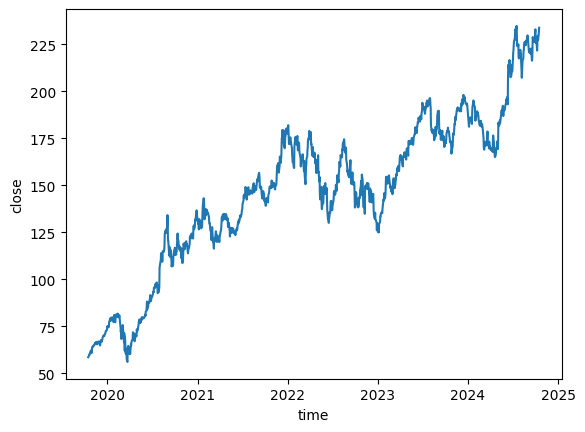

In [88]:
# plot the data
ds["close"].plot()

In [89]:
ds.plot_candlestick()

In [90]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

def plot_candlestick(ds, from_date=None, to_date=None):
    if from_date is None:
        from_date = ds.time.values[-1] - np.timedelta64(14, 'D')
    if to_date is None:
        to_date = ds.time.values[-1]
        
    data = ds.sel(time=slice(from_date, to_date))

    fig = go.Figure(data=[go.Candlestick(x=data.time.values,
                                            open=data.open.values,
                                            high=data.high.values,
                                            low=data.low.values,
                                            close=data['close'].values)])
    
    fig.update_xaxes(type='category')
    fig.show()

In [91]:
ds.time.values[0]

np.datetime64('2019-10-16T00:00:00.000000000')

In [92]:
ds.time.values[-1] - np.timedelta64(14, "D")

np.datetime64('2024-10-01T00:00:00.000000000')

In [93]:
ds = ds.sel(time=slice(ds.time.values[-1] - np.timedelta64(14, "D"), ds.time.values[-1]))

In [94]:
ds

<xarray.FinDataset> Size: 2kB
Dimensions:           (time: 11)
Coordinates:
  * time              (time) datetime64[ns] 88B 2024-10-01 ... 2024-10-15
Data variables:
    open              (time) float64 88B 229.5 225.9 225.1 ... 229.3 228.7 233.6
    high              (time) float64 88B 229.7 227.4 226.8 ... 229.4 231.7 237.5
    low               (time) float64 88B 223.7 223.0 223.3 ... 227.3 228.6 232.4
    close             (time) float64 88B 226.2 226.8 225.7 ... 227.6 231.3 233.8
    adjClose          (time) float64 88B 226.2 226.8 225.7 ... 227.6 231.3 233.8
    volume            (time) int64 88B 63285048 32880605 ... 39882100 61901688
    unadjustedVolume  (time) int64 88B 63285048 32880605 ... 39882100 61901688
    change            (time) float64 88B -3.31 0.89 0.53 -1.1 ... -1.75 2.6 0.24
    changePercent     (time) float64 88B -1.44 0.394 0.2354 ... 1.14 0.1027
    vwap              (time) float64 88B 227.3 225.8 225.2 ... 228.4 230.1 234.3
    label             (time) <U16 704B 'October 01, 24' ... 'October 15, 24'
    changeOverTime    (time) float64 88B -0.0144 0.00394 ... 0.0114 0.001027

In [95]:
appl_ds = fmp.get_daily("AAPL")
msft_ds = fmp.get_daily("MSFT")
amzn_ds = fmp.get_daily("AMZN")
goog_ds = fmp.get_daily("GOOG")

In [96]:
appl_ds

<xarray.FinDataset> Size: 201kB
Dimensions:           (time: 1258)
Coordinates:
  * time              (time) datetime64[ns] 10kB 2019-10-16 ... 2024-10-15
Data variables:
    open              (time) float64 10kB 58.34 58.77 58.65 ... 228.7 233.6
    high              (time) float64 10kB 58.81 59.04 59.4 ... 229.4 231.7 237.5
    low               (time) float64 10kB 58.3 58.38 58.57 ... 227.3 228.6 232.4
    close             (time) float64 10kB 58.59 58.82 59.1 ... 227.6 231.3 233.8
    adjClose          (time) float64 10kB 56.7 56.92 57.19 ... 227.6 231.3 233.8
    volume            (time) int64 10kB 77146776 69091588 ... 39882100 61901688
    unadjustedVolume  (time) int64 10kB 77146776 69091588 ... 39882100 61901688
    change            (time) float64 10kB 0.25 0.0475 0.455 ... -1.75 2.6 0.24
    changePercent     (time) float64 10kB 0.4285 0.08508 0.7673 ... 1.14 0.1027
    vwap              (time) float64 10kB 58.51 58.75 58.93 ... 230.1 234.3
    label             (time) <U16 81kB 'October 16, 19' ... 'October 15, 24'
    changeOverTime    (time) float64 10kB 0.004285 0.0008508 ... 0.0114 0.001027

In [97]:
portfolio = qs.Portfolio()

In [98]:
portfolio.add_security("AAPL")
portfolio.add_security("MSFT")

In [99]:
portfolio.fmp

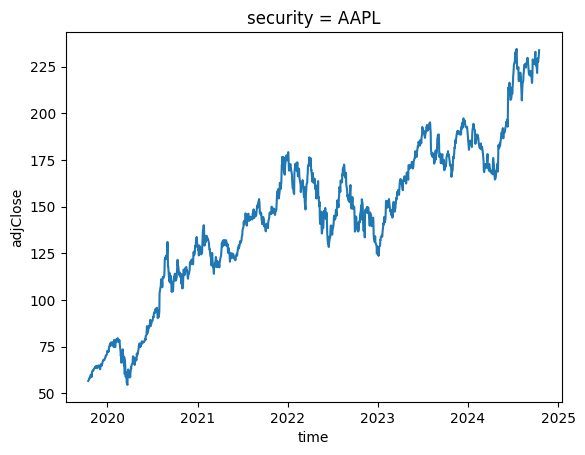

In [100]:
portfolio.data["adjClose"].sel(security="AAPL").plot()

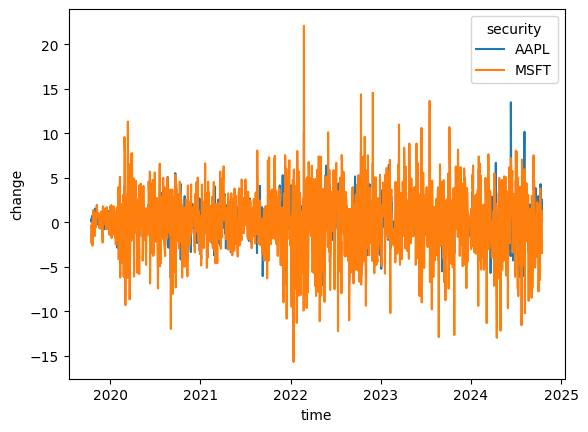

In [101]:
portfolio.data["change"].plot.line(x="time", hue="security")

In [102]:
portfolio.calculate_metrics()

In [103]:
portfolio.data

<xarray.Dataset> Size: 352kB
Dimensions:                  (security: 2, time: 1258)
Coordinates:
  * security                 (security) object 16B 'AAPL' 'MSFT'
  * time                     (time) datetime64[ns] 10kB 2019-10-16 ... 2024-1...
Data variables: (12/17)
    open                     (security, time) float64 20kB 58.34 58.77 ... 422.2
    high                     (security, time) float64 20kB 58.81 59.04 ... 422.5
    low                      (security, time) float64 20kB 58.3 58.38 ... 415.3
    close                    (security, time) float64 20kB 58.59 58.82 ... 418.7
    adjClose                 (security, time) float64 20kB 56.7 56.92 ... 418.7
    volume                   (security, time) float64 20kB 7.715e+07 ... 1.76...
    ...                       ...
    changeOverTime           (security, time) float64 20kB 0.004285 ... -0.00...
    cumulative_return        (security, time) float64 20kB 0.0 ... 1.982
    avg_daily_return         (security, time) float64 20kB 0.001301 ... 0.001052
    std_dev                  (security, time) float64 20kB 0.01997 ... 0.01907
    sharpe_ratio             (security, time) float64 20kB 0.06117 ... 0.05098
    annualized_sharpe_ratio  (security, time) float64 20kB 0.971 ... 0.8093
Attributes:
    risk_free_rate:       0.02
    annual_trading_days:  252

In [104]:
portfolio.data["cumulative_return"].sel(security="AAPL").values

array([0.        , 0.00392558, 0.00870456, ..., 2.88376856, 2.94777266,
       2.99129544])

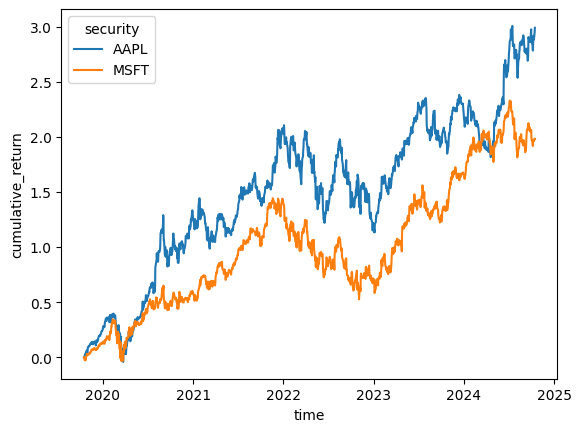

In [105]:
portfolio.plot_cumulative_returns()